<font size="+3">Correlation between peptide conformations and AF3 performance</font> <br>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

from Bio import PDB
from Bio.PDB import MMCIFParser, PDBIO, Superimposer

from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import spearmanr

# Analyze AF3 output

In [5]:
topdir = 'standard'
df = pd.read_csv(f'{topdir}/AF3_class_I_output.csv')
df

,id,peptide,MHC_allele_a,epitope,AF3_iptm_pair_mean,batch
0,tcr_00001,TTDPSFLGRY,HLA_A0101,A0101_TTDPSFLGRY,0.8100,positives
1,tcr_00002,TTDPSFLGRY,HLA_A0101,A0101_TTDPSFLGRY,0.2050,positives
2,tcr_00003,TTDPSFLGRY,HLA_A0101,A0101_TTDPSFLGRY,0.7800,positives
3,tcr_00004,TTDPSFLGRY,HLA_A0101,A0101_TTDPSFLGRY,0.1300,positives
4,tcr_00005,TTDPSFLGRY,HLA_A0101,A0101_TTDPSFLGRY,0.6675,positives
...,...,...,...,...,...,...
895,tcr_00446,RAKFKQLL,HLA_B0801,B0801_RAKFKQLL,0.4850,negatives
896,tcr_00447,RAKFKQLL,HLA_B0801,B0801_RAKFKQLL,0.6450,negatives
897,tcr_00448,RAKFKQLL,HLA_B0801,B0801_RAKFKQLL,0.4075,negatives
898,tcr_00449,RAKFKQLL,HLA_B0801,B0801_RAKFKQLL,0.3500,negatives


# Align models

In [9]:
BASE_DIR = "/Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard"
CSV_PATH = os.path.join(BASE_DIR, "AF3_class_I_output.csv")
POSITIVES_DIR = os.path.join(BASE_DIR, "positives", "AF3_outputs")
ALIGNED_DIR = os.path.join(BASE_DIR, "positives", "aligned")

df = pd.read_csv(CSV_PATH)
df = df[df["batch"] == "positives"]

parser = MMCIFParser(QUIET=True)
sup = Superimposer()
io = MMCIFIO()

ALIGN_CHAIN = "MHC"

for epitope, group in df.groupby("epitope"):
    ids = group["id"].tolist()
    out_dir = os.path.join(ALIGNED_DIR, epitope)
    os.makedirs(out_dir, exist_ok=True)

    structures = {}
    for sid in ids:
        cif_path = os.path.join(POSITIVES_DIR, sid, f"{sid}_model.cif")
        if os.path.exists(cif_path):
            structures[sid] = parser.get_structure(sid, cif_path)
        else:
            print(f"Missing: {cif_path}")

    if len(structures) < 1:
        continue

    ref_id = list(structures.keys())[0]
    ref_struct = structures[ref_id]

    def get_ca_atoms(struct, chain_id):
        chain = struct[0][chain_id]
        return [r["CA"] for r in chain.get_residues() if r.has_id("CA")]

    ref_ca = get_ca_atoms(ref_struct, ALIGN_CHAIN)

    for sid, struct in structures.items():
        if sid == ref_id:
            io.set_structure(struct)
            io.save(os.path.join(out_dir, f"{sid}.cif"))
            continue

        mob_ca = get_ca_atoms(struct, ALIGN_CHAIN)
        sup.set_atoms(ref_ca, mob_ca)
        sup.apply(struct.get_atoms())

        io.set_structure(struct)
        io.save(os.path.join(out_dir, f"{sid}.cif"))

    print(f"{epitope}: aligned {len(structures)} structures -> {out_dir}")

A0101_TTDPSFLGRY: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0101_TTDPSFLGRY
A0201_GILGFVFTL: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0201_GILGFVFTL
A0201_GLCTLVAML: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0201_GLCTLVAML
A0201_LLAGIGTVPI: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0201_LLAGIGTVPI
A0201_LLWNGPMAV: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0201_LLWNGPMAV
A0201_NLVPMVATV: aligned 50 structures -> /Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard/positives/aligned/A0201_NLVPMVATV
A0201_

# Peptide conformational diversity

In [10]:
BASE_DIR = "/Users/roessner/Documents/PostDoc/Data/260609_af3_benchmark_mod_template_search/standard"
CSV_PATH = os.path.join(BASE_DIR, "AF3_class_I_output.csv")
ALIGNED_DIR = os.path.join(BASE_DIR, "positives", "aligned")

df = pd.read_csv(CSV_PATH)
df = df[df["batch"] == "positives"]

parser = MMCIFParser(QUIET=True)

PEPTIDE_CHAIN = "PEPTIDE"

def get_peptide_ca(struct):
    chain = struct[0][PEPTIDE_CHAIN]
    return [r["CA"] for r in chain.get_residues() if r.has_id("CA")]

def ca_plddt(ca_atoms):
    return np.mean([a.bfactor for a in ca_atoms])

def ca_rmsd(atoms1, atoms2):
    coords1 = np.array([a.coord for a in atoms1])
    coords2 = np.array([a.coord for a in atoms2])
    return np.sqrt(np.mean(np.sum((coords1 - coords2) ** 2, axis=1)))

records = []

for epitope, group in df.groupby("epitope"):
    ids = group["id"].tolist()
    epitope_dir = os.path.join(ALIGNED_DIR, epitope)

    structures = {}
    plddts = {}
    for sid in ids:
        cif_path = os.path.join(epitope_dir, f"{sid}.cif")
        if os.path.exists(cif_path):
            struct = parser.get_structure(sid, cif_path)
            ca_atoms = get_peptide_ca(struct)
            structures[sid] = ca_atoms
            plddts[sid] = ca_plddt(ca_atoms)
        else:
            print(f"Missing: {cif_path}")

    if len(structures) < 1:
        continue

    ref_id = max(plddts, key=plddts.get)
    ref_ca = structures[ref_id]

    for sid, ca_atoms in structures.items():
        rmsd = ca_rmsd(ref_ca, ca_atoms) if sid != ref_id else 0.0
        records.append({
            "epitope": epitope,
            "id": sid,
            "peptide_ca_plddt": plddts[sid],
            "ref_id": ref_id,
            "ref_plddt": plddts[ref_id],
            "peptide_ca_rmsd": rmsd,
        })

results = pd.DataFrame(records)
results.to_csv(f"{ALIGNED_DIR}/peptide_rmsd.csv", index=False)

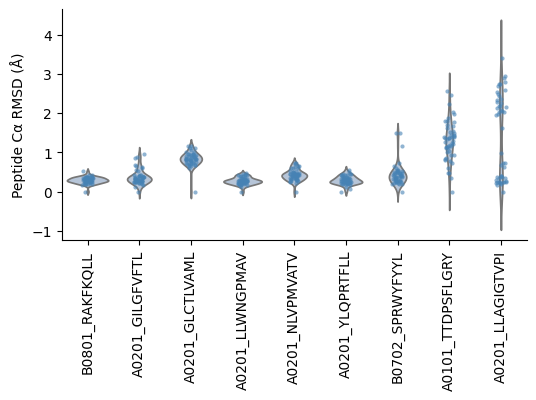

In [15]:
# derive peptide length from epitope name (format: ALLELE_PEPTIDE)
results["peptide_len"] = results["epitope"].str.split("_").str[1].str.len()

epitope_order = (
    results[["epitope", "peptide_len"]]
    .drop_duplicates()
    .sort_values("peptide_len")
    ["epitope"]
    .tolist()
)

fig, ax = plt.subplots(figsize=(6,3))

sns.violinplot(
    data=results,
    x="epitope", y="peptide_ca_rmsd",
    order=epitope_order,
    inner=None,
    color="lightsteelblue",
    ax=ax,
)
sns.stripplot(
    data=results,
    x="epitope", y="peptide_ca_rmsd",
    order=epitope_order,
    color="steelblue", alpha=0.6, size=3, jitter=True,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Peptide Cα RMSD (Å)")
ax.tick_params(axis="x", rotation=90)
sns.despine()

# Correlate conformational diversity with AF3 performance

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_17317/1095536339.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(epitope_auc)


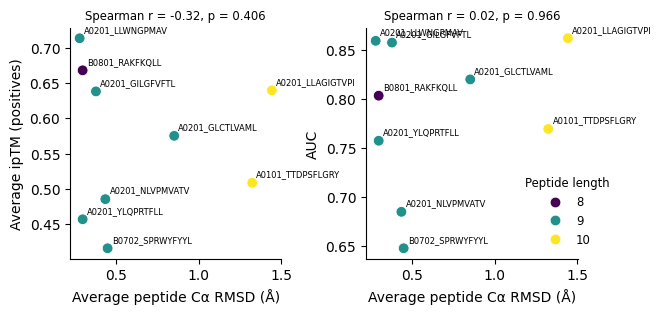

In [41]:
df_all = pd.read_csv(CSV_PATH)

# per-epitope average RMSD (reference excluded since its RMSD=0 by definition)
avg_rmsd = (
    results[results["peptide_ca_rmsd"] > 0]
    .groupby("epitope")["peptide_ca_rmsd"]
    .mean()
    .rename("avg_rmsd")
)

# per-epitope average iptm of positives
avg_iptm = (
    df_all[df_all["batch"] == "positives"]
    .groupby("epitope")["AF3_iptm_pair_mean"]
    .mean()
    .rename("avg_iptm")
)

# per-epitope AUC
def epitope_auc(grp):
    scores = grp["AF3_iptm_pair_mean"].values
    labels = (grp["batch"] == "positives").astype(int).values
    if labels.sum() == 0 or (1 - labels).sum() == 0:
        return np.nan
    return roc_auc_score(labels, scores)

auc_per_epitope = (
    df_all.groupby("epitope")
    .apply(epitope_auc)
    .rename("auc")
)

summary = pd.concat([avg_rmsd, avg_iptm, auc_per_epitope], axis=1).dropna()
summary["peptide_len"] = summary.index.str.split("_").str[1].str.len()

# plot
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

for ax, (ycol, ylabel) in zip(axes, [
    ("avg_iptm", "Average ipTM (positives)"),
    ("auc",      "AUC"),
]):
    sns.scatterplot(data=summary, x="avg_rmsd", y=ycol, hue="peptide_len",
                    palette="viridis", s=60, ax=ax)
    # correlation annotation
    r, p = spearmanr(summary["avg_rmsd"], summary[ycol])
    ax.set_xlabel("Average peptide Cα RMSD (Å)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Spearman r = {r:.2f}, p = {p:.3f}", fontsize='small')
    ax.legend([], [], frameon=False)

    for epitope, row in summary.iterrows():
        ax.annotate(epitope, (row["avg_rmsd"], row[ycol]),
                    fontsize=6, ha="left", va="bottom",
                    xytext=(3, 3), textcoords="offset points")
    
axes[1].legend(title="Peptide length", bbox_to_anchor=(1.2, 0.4), fontsize='small', frameon=False, title_fontsize='small')
sns.despine()
plt.subplots_adjust(wspace=0.4, right=0.85)